In [1]:
%load_ext autoreload
%autoreload 2

import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from concurrent.futures import ProcessPoolExecutor

from src.experiments_analysis.cell_typing_pipeline import (
    load_benchmark_config,
    rescale_sdata_expression,
)
from src.spatialAdata.loading import load_spatialAdata

logging.basicConfig(level=logging.INFO)

In [ ]:
YAML_PATH = "experiments/benchmark_output_files/zebrafish_head.yaml"
REGIONS_DIR = Path("resources")
GENE_OI = "foxd1"
ALPHA = 0.05
N_HVG = 2000

cfg = load_benchmark_config(YAML_PATH)
methods = list(cfg["methods"].keys())
print(f"Methods: {methods}")

sdata_raw = load_spatialAdata(cfg["sdata_path"])

## Region selection

In [3]:
# # --- Interactive lasso selection (uncomment to re-draw regions) ---
# %matplotlib ipympl
# from matplotlib.widgets import LassoSelector
# from matplotlib.path import Path as MplPath
#
# he_img = sdata_raw.get_img("0.5_mpp")
# coords_he = sdata_raw.get_unscaled_coordinates("0.5_mpp")
# plot_xy_he = np.column_stack([coords_he[:, 1], coords_he[:, 0]])
#
# n_total_he = len(plot_xy_he)
# MAX_DISPLAY_HE = 200_000
# if n_total_he > MAX_DISPLAY_HE:
#     display_idx_he = np.random.default_rng(42).choice(n_total_he, MAX_DISPLAY_HE, replace=False)
# else:
#     display_idx_he = np.arange(n_total_he)
#
# # --- Eye selection ---
# lasso_vertices_eye = []
# def on_lasso_eye(verts):
#     lasso_vertices_eye.clear()
#     lasso_vertices_eye.extend(verts)
#     path = MplPath(verts)
#     inside = path.contains_points(plot_xy_he[display_idx_he])
#     scatter_eye.set_color(np.where(inside, "red", "none"))
#     fig_eye.canvas.draw_idle()
#     print(f"Selected {inside.sum()} / {len(display_idx_he)} displayed points")
#
# fig_eye, ax_eye = plt.subplots(figsize=(10, 8))
# ax_eye.imshow(he_img, origin="upper", aspect="equal")
# scatter_eye = ax_eye.scatter(plot_xy_he[display_idx_he, 0], plot_xy_he[display_idx_he, 1],
#     c="none", edgecolors="cyan", s=0.2, alpha=0.15, linewidths=0.3)
# ax_eye.set_title("Draw lasso around the EYE region")
# LassoSelector(ax_eye, on_lasso_eye)
# plt.show()

# # --- Gill selection ---
# lasso_vertices_gill = []
# def on_lasso_gill(verts):
#     lasso_vertices_gill.clear()
#     lasso_vertices_gill.extend(verts)
#     path = MplPath(verts)
#     inside = path.contains_points(plot_xy_he[display_idx_he])
#     scatter_gill.set_color(np.where(inside, "lime", "none"))
#     fig_gill.canvas.draw_idle()
#     print(f"Selected {inside.sum()} / {len(display_idx_he)} displayed points")
#
# fig_gill, ax_gill = plt.subplots(figsize=(10, 8))
# ax_gill.imshow(he_img, origin="upper", aspect="equal")
# scatter_gill = ax_gill.scatter(plot_xy_he[display_idx_he, 0], plot_xy_he[display_idx_he, 1],
#     c="none", edgecolors="cyan", s=0.2, alpha=0.15, linewidths=0.3)
# ax_gill.set_title("Draw lasso around the GILL region")
# LassoSelector(ax_gill, on_lasso_gill)
# plt.show()

# # --- Apply masks and save ---
# %matplotlib inline
# eye_mask = MplPath(lasso_vertices_eye).contains_points(plot_xy_he)
# gill_mask = MplPath(lasso_vertices_gill).contains_points(plot_xy_he)
# eye_labels = np.where(eye_mask, "eye", "rest")
# gill_labels = np.where(gill_mask, "gill", "rest")
# REGIONS_DIR.mkdir(parents=True, exist_ok=True)
# np.save(REGIONS_DIR / "eye.npy", eye_labels)
# np.save(REGIONS_DIR / "gill.npy", gill_labels)
# print(f"Saved eye ({eye_mask.sum()} bins) and gill ({gill_mask.sum()} bins) to {REGIONS_DIR}")

In [ ]:
from pathlib import Path as P

savepath = (
    "results/publication_oup_vrepro/downstream_tasks/zebrafish_dge/regions.pdf"
)
P(savepath).parent.mkdir(parents=True, exist_ok=True)

# Load pre-computed region labels (from interactive lasso selection on H&E)
eye_labels = np.load(REGIONS_DIR / "zebrafish_eye_region.npy", allow_pickle=True)
gill_labels = np.load(REGIONS_DIR / "zebrafish_gill_region.npy", allow_pickle=True)

combined_labels = np.full(len(eye_labels), "other", dtype=object)
combined_labels[eye_labels == "eye"] = "eye"
combined_labels[gill_labels == "gill"] = "gill"

print(f"Eye: {(combined_labels == 'eye').sum()}, Gill: {(combined_labels == 'gill').sum()}, Other: {(combined_labels == 'other').sum()}")

# Plot both regions on H&E
he_img = sdata_raw.get_img("0.5_mpp")
coords_he = sdata_raw.get_coordinates("0.5_mpp")

fig, ax = plt.subplots(figsize=(3.4, 3))
ax.imshow(he_img, origin="upper", aspect="equal")
for label, color in [("eye", "red"), ("gill", "lime")]:
    mask = combined_labels == label
    ax.scatter(coords_he[mask, 1], coords_he[mask, 0], c=color, s=0.001, alpha=0.2, rasterized=True)
# Manual legend handles with visible marker size
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=l)
           for l, c in [("eye", "red"), ("gill", "lime")]]
ax.legend(handles=handles)
ax.axis("off")
# ax.set_title("Region selection: eye and gill")
plt.tight_layout()
plt.savefig(savepath)
plt.show()

## Expression of foxd1

,method,U,p,log2fc,mean_eye,mean_gill
0,ours,1.159720e+11,0.002557,0.000050,0.000051,0.000017
1,original,1.159720e+11,0.002556,0.000050,0.000051,0.000016
2,b2c,1.159720e+11,0.002557,-0.000144,0.000039,0.000139
3,b2c-sym,1.159720e+11,0.002557,-0.000166,0.000012,0.000128


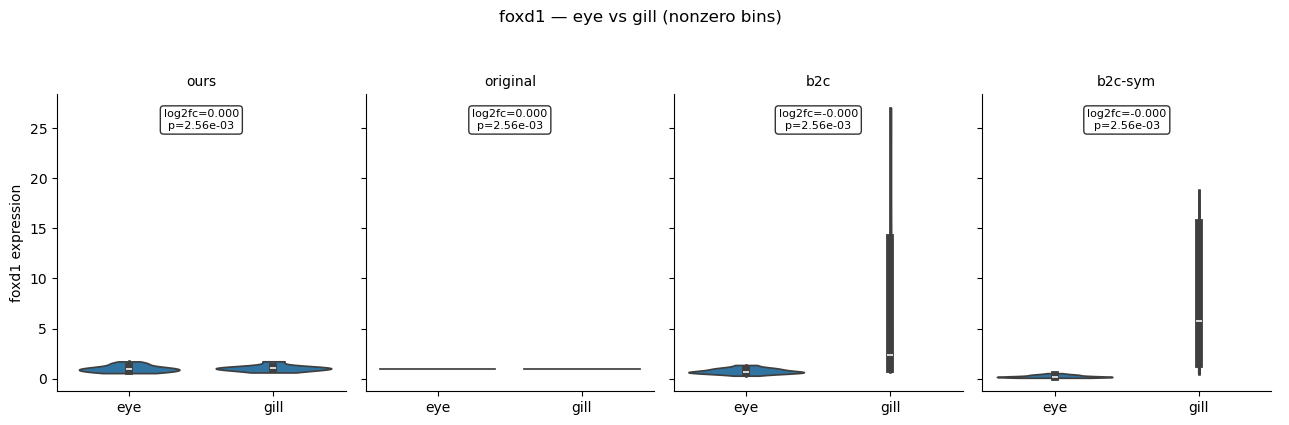

In [ ]:
# Mann-Whitney U test for foxd1: eye vs gill
foxd1_stats = []
foxd1_records = []
for method_name in methods:
    destriped_df = pd.read_parquet(cfg["methods"][method_name])
    rescaled = rescale_sdata_expression(sdata_raw, destriped_df)
    expr = rescaled.adata[:, GENE_OI].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    expr = np.asarray(expr).squeeze()

    eye_expr = expr[combined_labels == "eye"]
    gill_expr = expr[combined_labels == "gill"]
    stat, pval = mannwhitneyu(eye_expr, gill_expr, alternative="two-sided")
    log2fc = np.log2(eye_expr.mean() + 1) - np.log2(gill_expr.mean() + 1)

    foxd1_stats.append({"method": method_name, "U": stat, "p": pval, "log2fc": log2fc,
                         "mean_eye": eye_expr.mean(), "mean_gill": gill_expr.mean()})

    # For violin plot: nonzero eye+gill bins only
    for region, vals in [("eye", eye_expr), ("gill", gill_expr)]:
        nz = vals[vals > 0]
        foxd1_records.extend({"expression": v, "region": region, "method": method_name} for v in nz)

foxd1_stats_df = pd.DataFrame(foxd1_stats)
display(foxd1_stats_df)


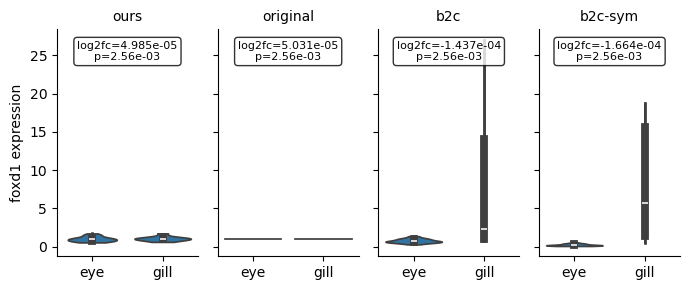

In [36]:
from pathlib import Path as P
savepath = (
    "results/publication_oup_vrepro/downstream_tasks/zebrafish_dge/fox1d_expression.pdf"
)
P(savepath).parent.mkdir(parents=True, exist_ok=True)

# Violin plot annotated with log2fc and p-value
foxd1_df = pd.DataFrame(foxd1_records)
g = sns.catplot(
    data=foxd1_df, x="region", y="expression", col="method",
    kind="violin", height=4, aspect=0.8, cut=0, order=["eye", "gill"], ax=ax
)
for ax, (_, row) in zip(g.axes.flat, foxd1_stats_df.iterrows()):
    ax.text(0.5, 0.95, f"log2fc={row['log2fc']:.3e}\np={row['p']:.2e}",
            transform=ax.transAxes, ha="center", va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
g.set_titles(col_template="{col_name}")
g.set_xlabels("")
g.set_ylabels(f"{GENE_OI} expression")
g.figure.set_size_inches(7, 3)
plt.savefig(savepath)
# g.figure.suptitle(f"{GENE_OI} — eye vs gill (nonzero bins)", y=1.05)
plt.tight_layout()
plt.show()

## DE gene selection

In [ ]:
from tqdm.auto import tqdm

def _test_one_gene(gene, eye_vals, gill_vals):
    stat, pval = mannwhitneyu(eye_vals, gill_vals, alternative="two-sided")
    mean_eye = eye_vals.mean()
    mean_gill = gill_vals.mean()
    log2fc = np.log2(mean_eye + 1) - np.log2(mean_gill + 1)
    return {"names": gene, "U_stat": stat, "pvals": pval, "log2fc": log2fc,
            "mean_eye": mean_eye, "mean_gill": mean_gill}

# Identify HVGs once (normalized copy, for gene selection only)
_adata_tmp = rescale_sdata_expression(sdata_raw, pd.read_parquet(cfg["methods"][methods[0]])).adata.copy()
_adata_tmp.obs["region"] = combined_labels
_adata_tmp = _adata_tmp[_adata_tmp.obs["region"].isin(["eye", "gill"])].copy()
sc.pp.filter_genes(_adata_tmp, min_cells=10)
sc.pp.normalize_total(_adata_tmp, target_sum=1e4)
sc.pp.log1p(_adata_tmp)
sc.pp.highly_variable_genes(_adata_tmp, flavor="seurat", n_top_genes=N_HVG)
hvg_genes = _adata_tmp.var_names[_adata_tmp.var.highly_variable].tolist()
del _adata_tmp

# Run Mann-Whitney U on raw rescaled counts for each method
all_dge = []
for method_name in methods:
    destriped_df = pd.read_parquet(cfg["methods"][method_name])
    rescaled = rescale_sdata_expression(sdata_raw, destriped_df)
    adata = rescaled.adata.copy()
    adata.obs["region"] = combined_labels
    adata = adata[adata.obs["region"].isin(["eye", "gill"])].copy()
    available = [g for g in hvg_genes if g in adata.var_names]
    adata = adata[:, available].copy()

    eye_idx = adata.obs["region"] == "eye"
    gill_idx = adata.obs["region"] == "gill"
    X_eye = adata[eye_idx].X
    X_gill = adata[gill_idx].X

    records = []
    for i, gene in enumerate(tqdm(available, desc=method_name)):
        ev = X_eye[:, i].toarray().ravel() if hasattr(X_eye, "toarray") else X_eye[:, i].ravel()
        gv = X_gill[:, i].toarray().ravel() if hasattr(X_gill, "toarray") else X_gill[:, i].ravel()
        records.append(_test_one_gene(gene, ev, gv))

    result = pd.DataFrame(records)
    _, result["pvals_adj"], _, _ = multipletests(result["pvals"], method="fdr_bh")
    result["method"] = method_name
    all_dge.append(result)

dge_df = pd.concat(all_dge, ignore_index=True)

ours: 1273 significant genes (alpha=0.05)
original: 1273 significant genes (alpha=0.05)
b2c: 1273 significant genes (alpha=0.05)
b2c-sym: 1275 significant genes (alpha=0.05)

--- DE gene set overlap ---


,ours,original,b2c,b2c-sym
ours,1273.0,1273.0,1273.0,1273.0
original,1273.0,1273.0,1273.0,1273.0
b2c,1273.0,1273.0,1273.0,1273.0
b2c-sym,1273.0,1273.0,1273.0,1275.0



--- log2fc sign agreement (% among shared significant genes) ---


,ours,original,b2c,b2c-sym
ours,100.0,100.0,56.0,48.0
original,100.0,100.0,56.0,48.0
b2c,56.0,56.0,100.0,92.0
b2c-sym,48.0,48.0,92.0,100.0


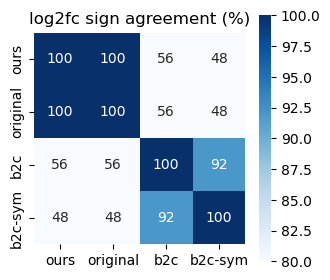


665 genes with disagreeing sign across all methods

Assertions passed: foxg1a, olfm1a, fgfr2 are positive in ours/original, negative in b2c and b2c-sym


,ours,original,b2c,b2c-sym
names,,,,
ppdpfa,0.082976,0.083197,0.051663,-1.491847e-02
CR383676.2,0.081785,0.080798,-0.025969,-1.527310e-01
ybx1,0.006096,0.006148,-0.009648,-2.627373e-02
rplp2,0.005222,0.005164,-0.007990,-2.246843e-02
rps3,0.004778,0.004844,-0.006094,-1.831124e-02
...,...,...,...,...
sstr1a,0.000022,0.000030,-0.000014,-1.149991e-04
zgc:171971,0.000021,0.000023,-0.000028,-1.416373e-04
neto1l,0.000021,0.000033,-0.000097,-1.457919e-04


In [38]:
from pathlib import Path as P

# --- Filter significant DE genes ---
sig_genes = {m: set(dge_df.loc[(dge_df["method"] == m) & (dge_df["pvals_adj"] < ALPHA), "names"])
             for m in methods}
for m, genes in sig_genes.items():
    print(f"{m}: {len(genes)} significant genes (alpha={ALPHA})")

# --- Agreement on DE gene sets (confusion-matrix style) ---
print("\n--- DE gene set overlap ---")
de_overlap = pd.DataFrame(index=methods, columns=methods, dtype=int)
for m1 in methods:
    for m2 in methods:
        de_overlap.loc[m1, m2] = len(sig_genes[m1] & sig_genes[m2])
display(de_overlap)

# --- Agreement on log2fc sign for shared DE genes ---
fc_by_method = {}
for m in methods:
    sub = dge_df[dge_df["method"] == m].set_index("names")
    fc_by_method[m] = sub["log2fc"]

# Pairwise sign agreement as integer percentage
sign_agreement = pd.DataFrame(index=methods, columns=methods, dtype=int)
for m1 in methods:
    for m2 in methods:
        shared = sig_genes[m1] & sig_genes[m2]
        if len(shared) == 0:
            sign_agreement.loc[m1, m2] = 0
            continue
        shared_list = list(shared)
        same = ((fc_by_method[m1].loc[shared_list] > 0) == (fc_by_method[m2].loc[shared_list] > 0)).sum()
        sign_agreement.loc[m1, m2] = round(100 * same / len(shared))

print("\n--- log2fc sign agreement (% among shared significant genes) ---")
display(sign_agreement)

savepath = "results/publication_oup_vrepro/downstream_tasks/zebrafish_dge/sign_agreement.pdf"
P(savepath).parent.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(3.4, 3))
sns.heatmap(sign_agreement.astype(int), annot=True, fmt="d", cmap="Blues", vmin=80, vmax=100, square=True, ax=ax)
ax.set_title("log2fc sign agreement (%)")
plt.tight_layout()
plt.savefig(savepath)
plt.show()

# --- Genes where sign disagrees across all methods ---
all_shared = set.intersection(*sig_genes.values())
fc_all = pd.DataFrame({m: fc_by_method[m].loc[list(all_shared)] for m in methods})
same_sign_all = (fc_all > 0).all(axis=1) | (fc_all < 0).all(axis=1)
disagree_genes = fc_all[~same_sign_all].sort_values(methods[0], key=lambda x: x.abs(), ascending=False)
print(f"\n{len(disagree_genes)} genes with disagreeing sign across all methods")

# Save
disagree_path = REGIONS_DIR.parent / "disagree_sign_genes.txt"
disagree_genes.index.to_series().to_csv(disagree_path, index=False, header=False)

# Assert expected genes
for gene in ["foxg1a", "olfm1a", "fgfr2"]:
    assert gene in disagree_genes.index, f"{gene} not in disagreeing genes"
    assert disagree_genes.loc[gene, "ours"] > 0, f"{gene} should be positive in ours"
    assert disagree_genes.loc[gene, "original"] > 0, f"{gene} should be positive in original"
    assert disagree_genes.loc[gene, "b2c"] < 0, f"{gene} should be negative in b2c"
    assert disagree_genes.loc[gene, "b2c-sym"] < 0, f"{gene} should be negative in b2c-sym"
print("\nAssertions passed: foxg1a, olfm1a, fgfr2 are positive in ours/original, negative in b2c and b2c-sym")

display(disagree_genes)

### Zebrafish genes reported in the eye or gill in adult zebrafish

- [`fgfr2`](https://zfin.org/ZDB-GENE-030323-1) — expression in the **lens** has been reported during zebrafish development.

**Others ?**
- `foxg1a`: ZFIN gene page — https://zfin.org/ZDB-GENE-990415-267
- `olfm1a`: ZFIN gene page — https://zfin.org/ZDB-GENE-040718-194
- `fgfr2`: ZFIN gene page — https://zfin.org/ZDB-GENE-030323-1, https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0030365&utm_source=chatgpt.com (adult Zebrafish)

Saved to results/publication_oup_vrepro/downstream_tasks/zebrafish_dge/fgfr2_expression.pdf


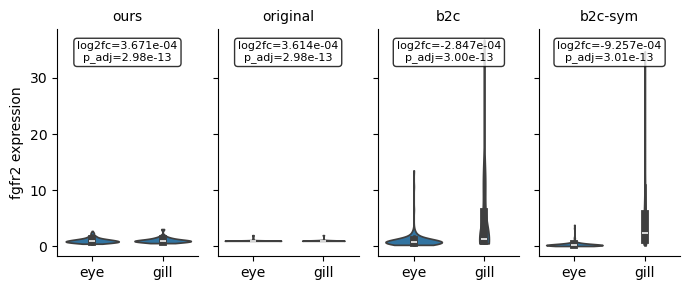

In [43]:
HIGHLIGHT_GENES = ["fgfr2"]
SAVE_DIR = Path("results/publication_oup_vrepro/downstream_tasks/zebrafish_dge")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for gene in HIGHLIGHT_GENES:
    # Build expression data
    gene_records = []
    for method_name in methods:
        destriped_df = pd.read_parquet(cfg["methods"][method_name])
        rescaled = rescale_sdata_expression(sdata_raw, destriped_df)
        expr = rescaled.adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray()
        expr = np.asarray(expr).squeeze()
        for region in ["eye", "gill"]:
            vals = expr[combined_labels == region]
            nz = vals[vals > 0]
            gene_records.extend({"expression": v, "region": region, "method": method_name} for v in nz)

    gene_df = pd.DataFrame(gene_records)

    # Get stats from dge_df
    gene_stats = dge_df[dge_df["names"] == gene][["method", "log2fc", "pvals_adj"]].set_index("method")

    g = sns.catplot(
        data=gene_df, x="region", y="expression", col="method",
        kind="violin", height=4, aspect=0.8, cut=0, order=["eye", "gill"],
    )
    for ax, method_name in zip(g.axes.flat, methods):
        if method_name in gene_stats.index:
            row = gene_stats.loc[method_name]
            ax.text(0.5, 0.95, f"log2fc={row['log2fc']:.3e}\np_adj={row['pvals_adj']:.2e}",
                    transform=ax.transAxes, ha="center", va="top", fontsize=8,
                    bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    g.set_titles(col_template="{col_name}")
    g.set_xlabels("")
    g.set_ylabels(f"{gene} expression")
    g.figure.set_size_inches(7, 3)
    plt.tight_layout()
    savepath = SAVE_DIR / f"{gene}_expression.pdf"
    plt.savefig(savepath)
    print(f"Saved to {savepath}")
    plt.show()